## Getting Dtw distance matrix

In [1]:
#import neccessary data
import numpy as np
import pickle
from dtaidistance import clustering, dtw_ndim, dtw
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


try:
    with open('operationList.pkl', 'rb') as f:
        operations = pickle.load(f)
except:
    print("Error")


In [2]:
distMatrix = dtw_ndim.distance_matrix(operations, ndim=57)


In [3]:
np.shape(distMatrix)

(24, 24)

## Running Tsne

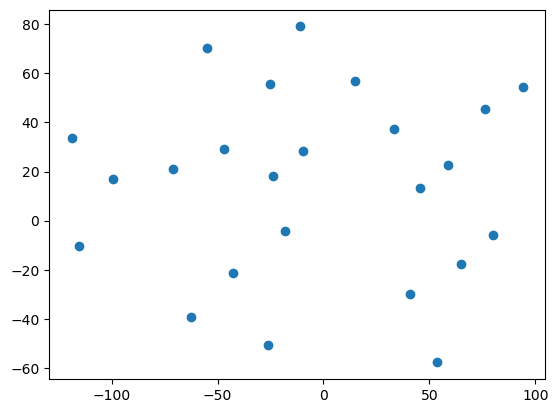

In [4]:
embedded = TSNE(n_components=2, metric='precomputed', random_state=42, init='random', perplexity = 5).fit_transform(distMatrix)


# plot
plt.scatter(embedded[:, 0], embedded[:, 1])
plt.show()

Data isnt showing any clusters clearly but since we dont procedure labels its hard to really tell whats going on

## Hiearchical clustering

In [5]:
from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage 

condensedDist = squareform(distMatrix) #flattening squared distMatrix for hiearchical clustering
x = linkage(condensedDist, method='complete') #linkage matrix

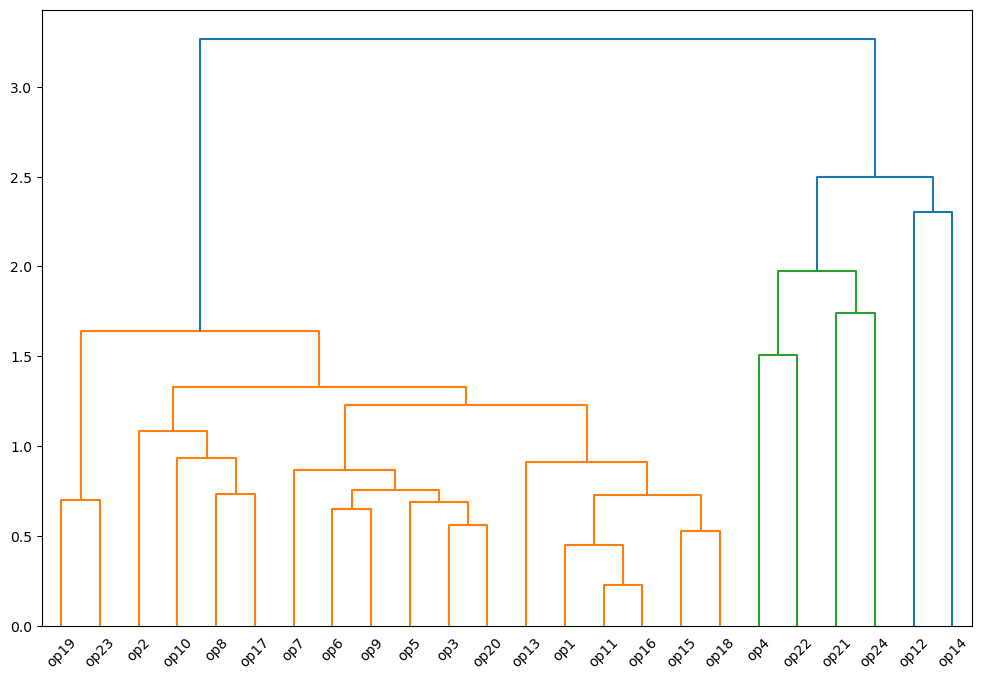

In [6]:
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt

opLabels = [f"op{i}" for i in range(1, 25)]

plt.figure(figsize=(12, 8))

dendrogram(x, labels = opLabels)
plt.show()

Observations:
- 3 main clusters: 
    - Seems to be clustered based on op length (in terms of frames)
    - Orange cluster far larger containing 19/24 operations, suggesting that green and blue clusters may be outliers
    - Blue frame len avg: 101 , Green frame len avg: 49,   compared to global avg of 24 frames

Will try dtw again with sakoe chiba band to see if that changes results

In [7]:
x_Chiba1 = clustering.LinkageTree(dtw_ndim.distance_matrix_fast, 
                                dists_options={"ndim": 57, "window": 5}).fit(operations) #tight constraint

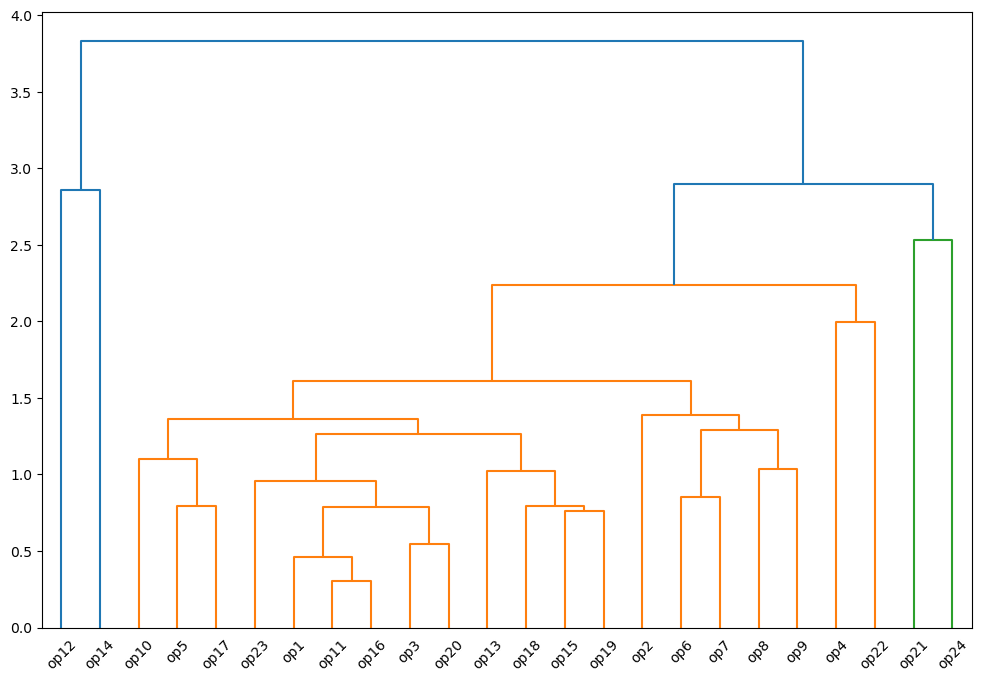

In [8]:
plt.figure(figsize=(12, 8))

dendrogram(x_Chiba1, labels = opLabels)
plt.show()

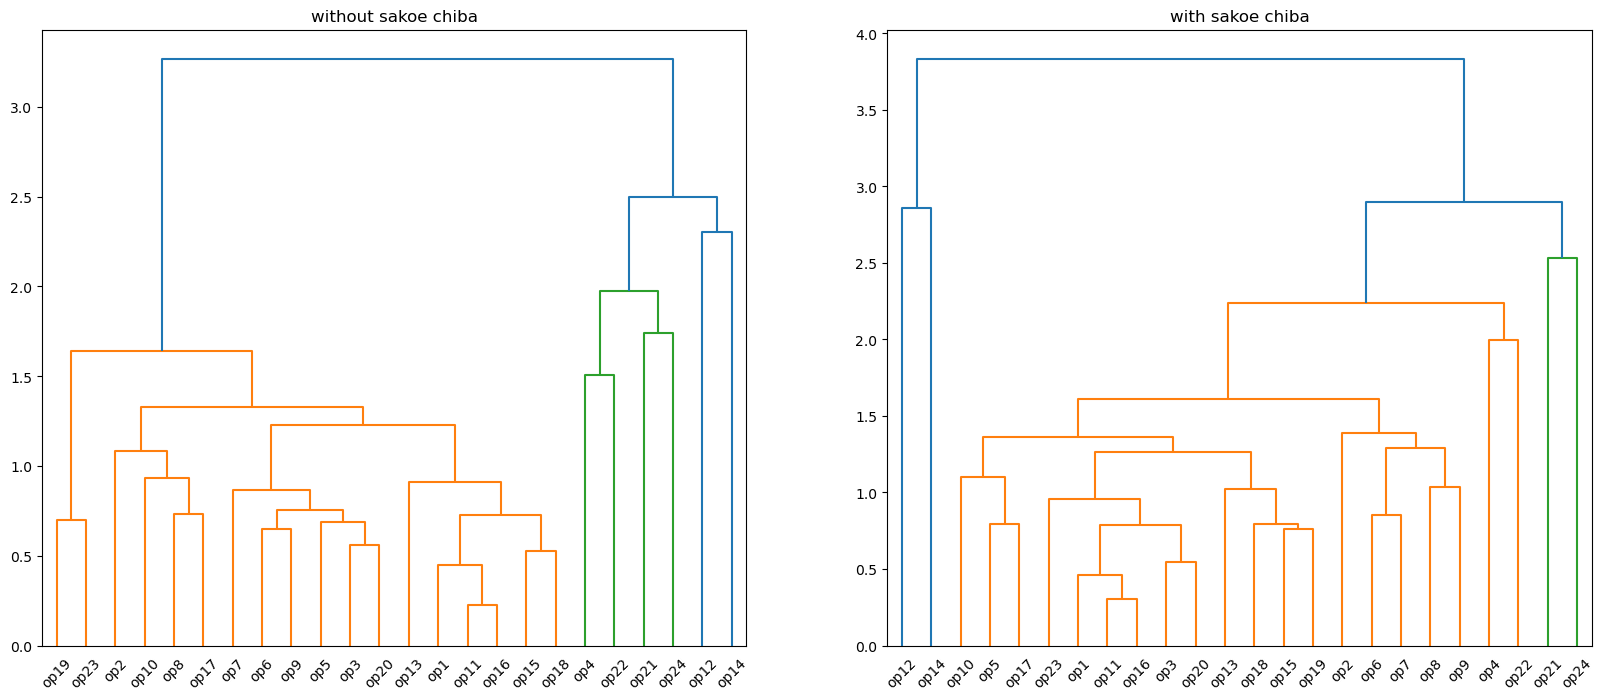

In [9]:
##plotting both side by side 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
dendrogram(x,  ax = ax1, labels = opLabels)
dendrogram(x_Chiba1, ax = ax2, labels = opLabels)

ax1.set_title("without sakoe chiba")
ax2.set_title("with sakoe chiba")

plt.show()



Adding sakoe chiba didnt help much due to the vast difference between largest and smallest frame. Will normalize dtw weights to see if that provides better results

### Retrying with DTW normalization

In [10]:
#seq = list of timesseries <-- operations
#returns normalized distance matrix
def n_dtw(seq, window = None):
    N = len(seq)
    distMatrix = np.zeros((N,N))

    for i in range(N):
        for j in range(i+1, N):
            dist, paths = dtw_ndim.warping_paths(seq[i], seq[j], window = window)
            pathLen = len(dtw.best_path(paths))
            normalizedDist = dist/pathLen
            distMatrix[i,j] = normalizedDist 
            distMatrix[j,i] = normalizedDist #making matrix symmetrical
    
    return distMatrix

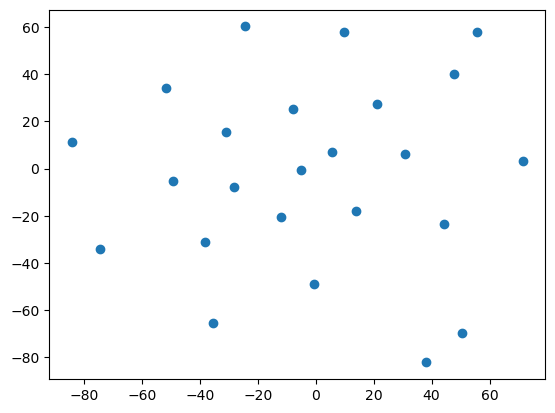

In [11]:
nDistMatrix = n_dtw(operations)
embedding = TSNE(n_components=2, metric='precomputed', 
                 random_state=42, init='random', 
                 perplexity=5).fit_transform(nDistMatrix)


# plot
plt.scatter(embedding[:, 0], embedding[:, 1])
plt.show()

still doesnt make much of a difference

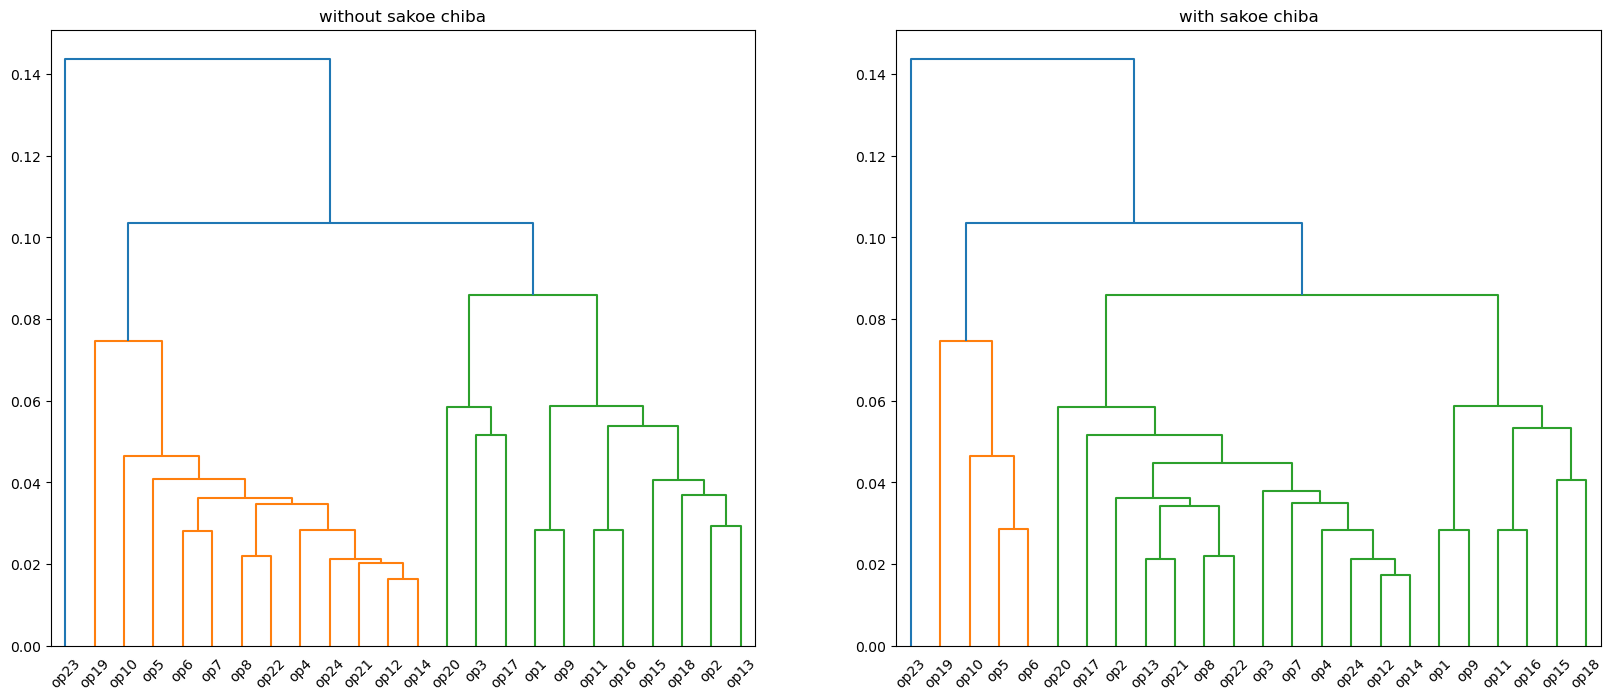

In [12]:
##hierachical clustering with and without sakoe chiba band
condensedDist = squareform(nDistMatrix) #flattening squared distMatrix for hiearchical clustering
x = linkage(condensedDist, method='complete') #linkage matrix


nDistMatrix2 = n_dtw(operations, window = 5)
condensedDist2 = squareform(nDistMatrix2) #flattening squared distMatrix for hiearchical clustering
x_Chiba = linkage(condensedDist2, method='complete') #linkage matrix

##plotting both side by side 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
dendrogram(x,  ax = ax1, labels = opLabels)
dendrogram(x_Chiba, ax = ax2, labels = opLabels)

ax1.set_title("without sakoe chiba")
ax2.set_title("with sakoe chiba")

plt.show()

Observations 
- 2 main clusters 
- After using ndtw, clusters seem to be more evenly distributed.
- Clusters are no longer operation length driven
    - ex: op8 and 22 are similar when operation 22 has way more frames
- operation 23 is an outlier alone in its own cluster which may be due to it having only 5 frames and having 3 clinicians consistently throughout it 

- Sakoe chiba band seems to be providing less evenly distributed clusters
- Would require labels for any further interpretation
    - Will cluster with other methods then obtain labels if cluster results overlap

In [13]:
#converting into flat labels
from scipy.cluster.hierarchy import fcluster

hierachical_labels = fcluster(x, t=3, criterion='maxclust') 

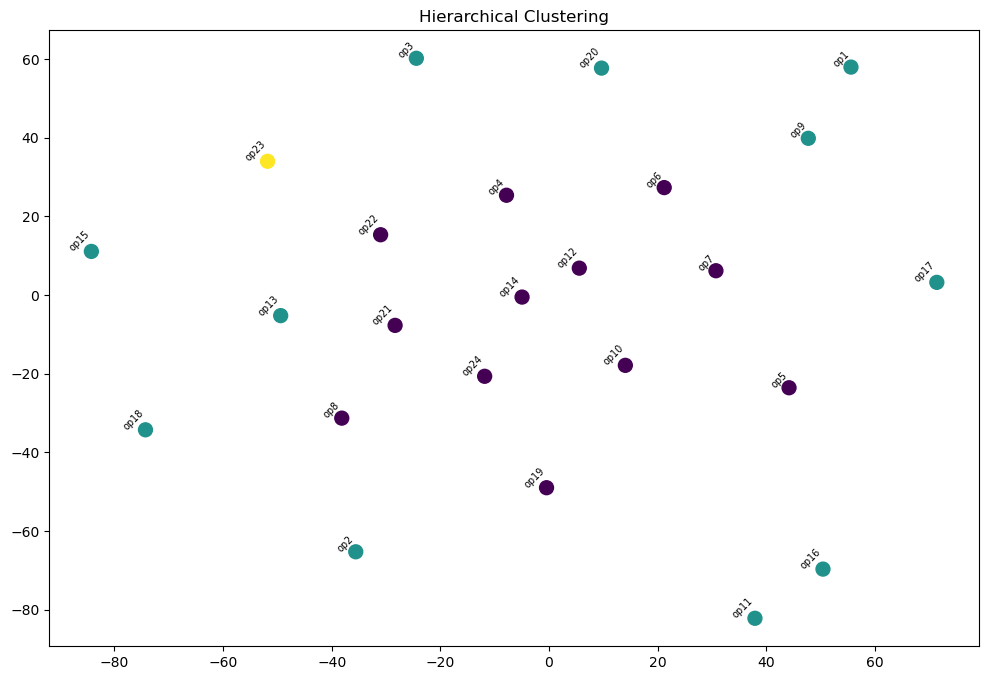

In [14]:
#visualizing
plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=hierachical_labels, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title('Hierarchical Clustering')
plt.show()

## K means with DBA

Since Kmeans is affected by initialization, we run k means multiples times and take best result (clustering with lowest inertia)

In [15]:
from dtaidistance.clustering.kmeans import KMeans

In [16]:
def multiple_KMeans(k=2, nRuns=10):
    results = {'inertia': 0.0}
    bestInertia = np.inf


    #distance: list of (cluster, distance from centroid) for each instance
    #clusteringEnded: boolean indicating whether the clustering has been stopped or not
    def computeInertia(distances, clusteringEnded):

        if clusteringEnded: #only compute when done
            results['inertia'] = sum(dist**2 for _, dist in distances)  

        return True #let it finish

    #finding best model
    for run in range(nRuns):
        model = KMeans(k=k, max_it = 100, max_dba_it = 100)
        cluster_idx = model.fit(operations, monitor_distances = computeInertia)

        #updating inertia 
        if results['inertia'] < bestInertia:
            bestInertia = results['inertia']
            bestCluster = cluster_idx
    
    #converting dict to flat array (should be [1,1,1,0,0....])
    cluster = np.zeros(len(operations))
    for cluster_id, op_indices in bestCluster[0].items():
        for idx in op_indices:
            cluster[idx] = cluster_id

    return bestInertia, cluster

In [17]:
inertia, cluster = multiple_KMeans()

  1%|          | 1/100 [00:05<08:19,  5.05s/it]


In [18]:
# #converting dict to flat array (should be [1,1,1,0,0....])
# cluster = np.zeros(len(operations))
# for cluster_id, op_indices in cluster_idx[0].items():
#     for idx in op_indices:
#         cluster[idx] = cluster_id

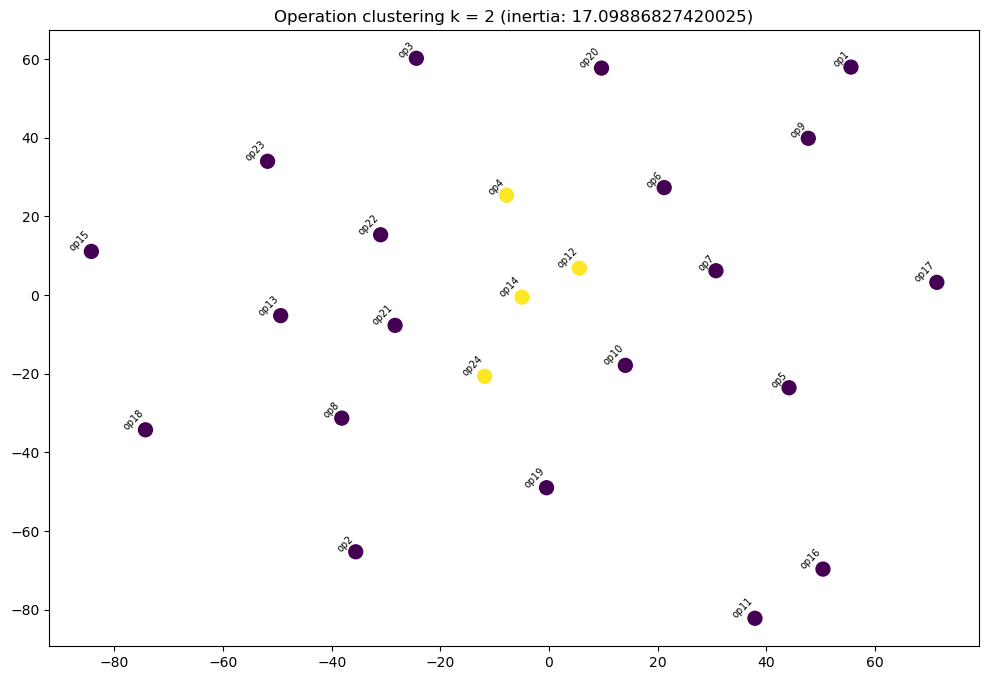

In [19]:
#plotting cluster assigments
plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=cluster, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title(f'Operation clustering k = 2 (inertia: {inertia})')
plt.show()

Observations:
- Very uneven clustering
- Seems to be clustering based on operation length once more 
- 2 Longest operations in one cluster, rest in other cluster


  3%|▎         | 3/100 [00:08<04:41,  2.90s/it]


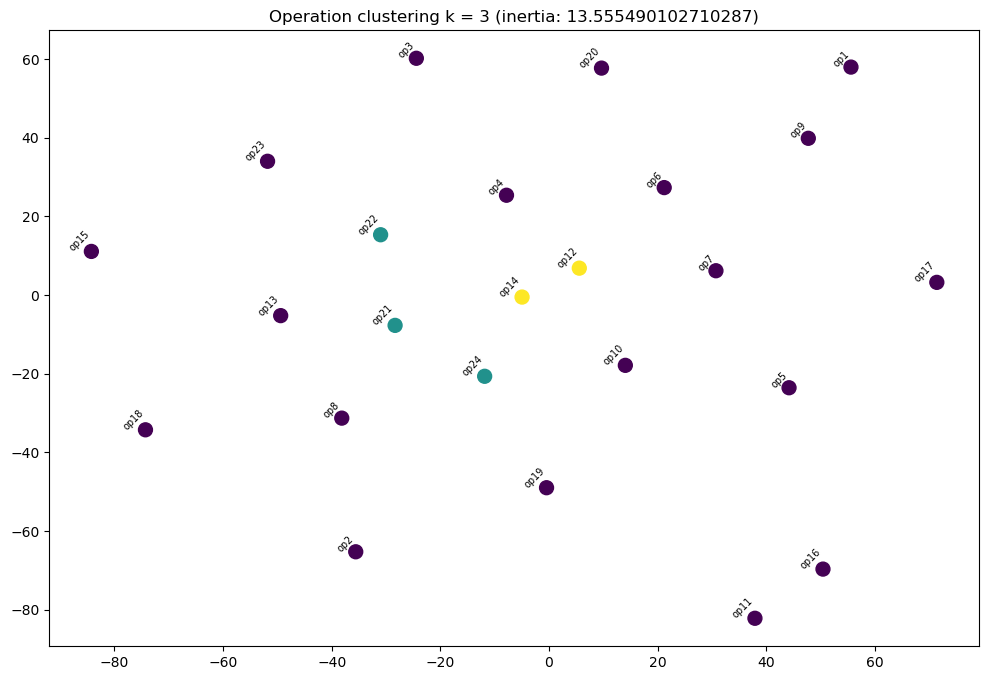

In [20]:
#trying different values of k

#k=3 following results of hiearchical clustering
inertia_k3, cluster_k3 = multiple_KMeans(k=3)
plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=cluster_k3, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title(f'Operation clustering k = 3 (inertia: {inertia_k3})')
plt.show()

Observations
- Cluster assigment is driven by operation length
    - Longest frame in its own cluster
    - Next 5 longest in second cluster
    - Rest in their own cluster

  3%|▎         | 3/100 [00:10<05:37,  3.48s/it]


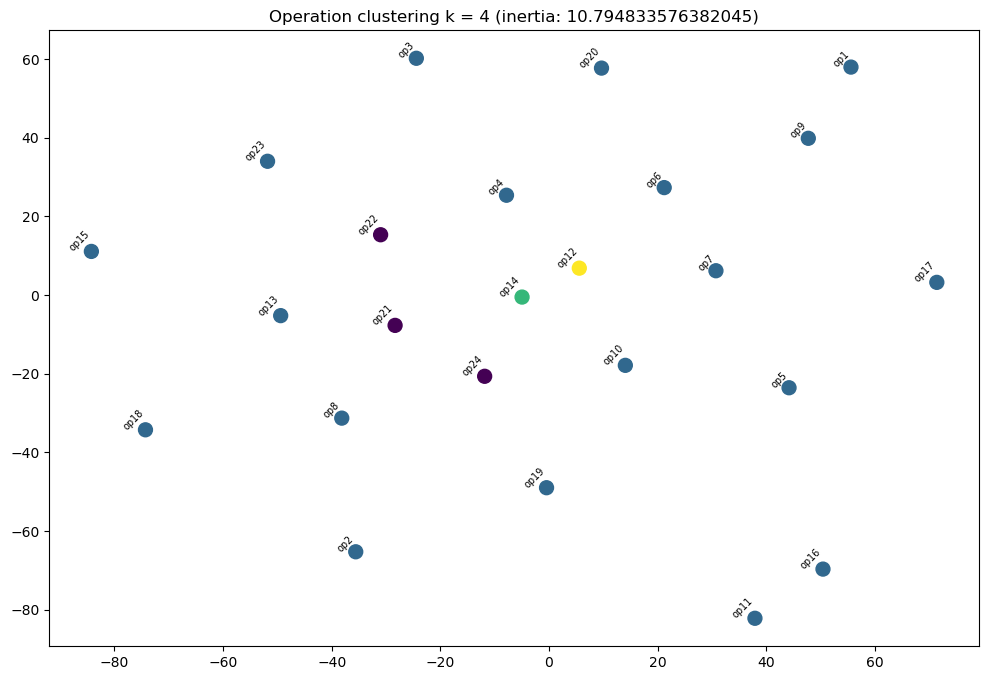

In [21]:

#k = 4, see if they cluster based on the days
inertia_k4, cluster_k4 = multiple_KMeans(k=4)
plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=cluster_k4, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title(f'Operation clustering k = 4 (inertia: {inertia_k4})')
plt.show()

Observations: 
- produced lower inertia than k=2 but algorithm still seemed to be catching operation length rather than actual pattenrns
    - 1st and 2nd longest ops in their own cluster 
    - 2 next longest in 3rd cluster
    - rest in 4th cluster


Results from Kmeans point towards using a version of algorithm more robust to length differences


## KMedioids 

In [22]:
from sklearn_extra.cluster import KMedoids
def multiple_KMedioids(k=2, nRuns=10):
    bestInertia = np.inf
    bestCluster = None 

    #finding best model
    for run in range(nRuns):
        kmed = KMedoids(n_clusters=k, metric='precomputed', random_state=run)
        cluster_kmed = kmed.fit_predict(nDistMatrix) 

        #updating inertia 
        if kmed.inertia_ < bestInertia:
            bestInertia = kmed.inertia_
            bestCluster = cluster_kmed
    
    return bestInertia, bestCluster 

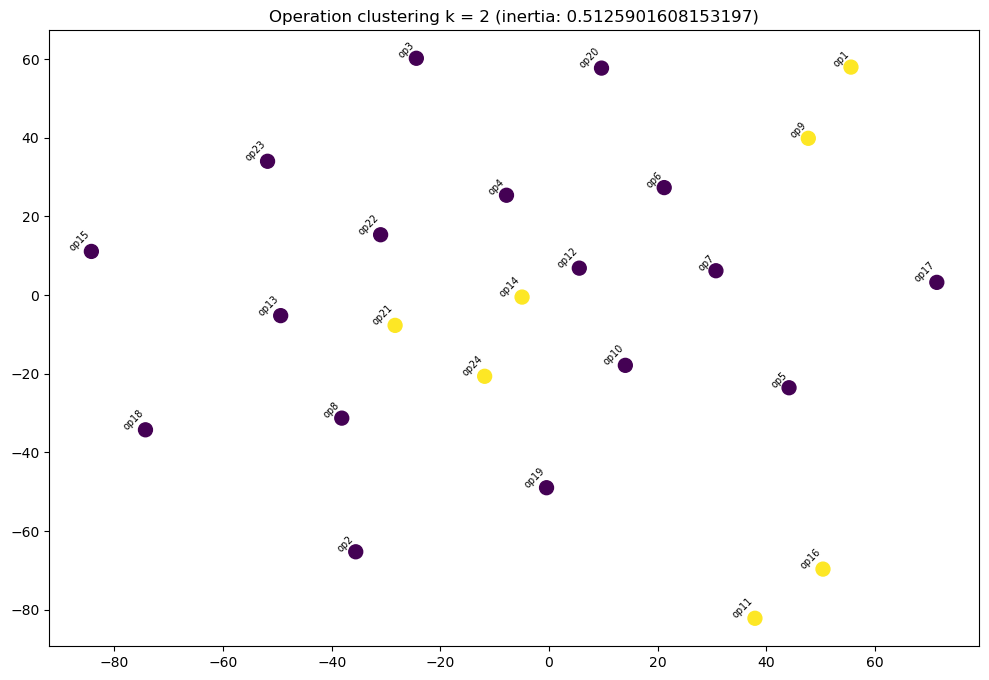

In [23]:
inertia, kmed_labels_k2 = multiple_KMedioids()

plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=kmed_labels_k2, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title(f'Operation clustering k = 2 (inertia: {inertia})')
plt.show()

- operations are no longer length driven
- cluster is fragmented

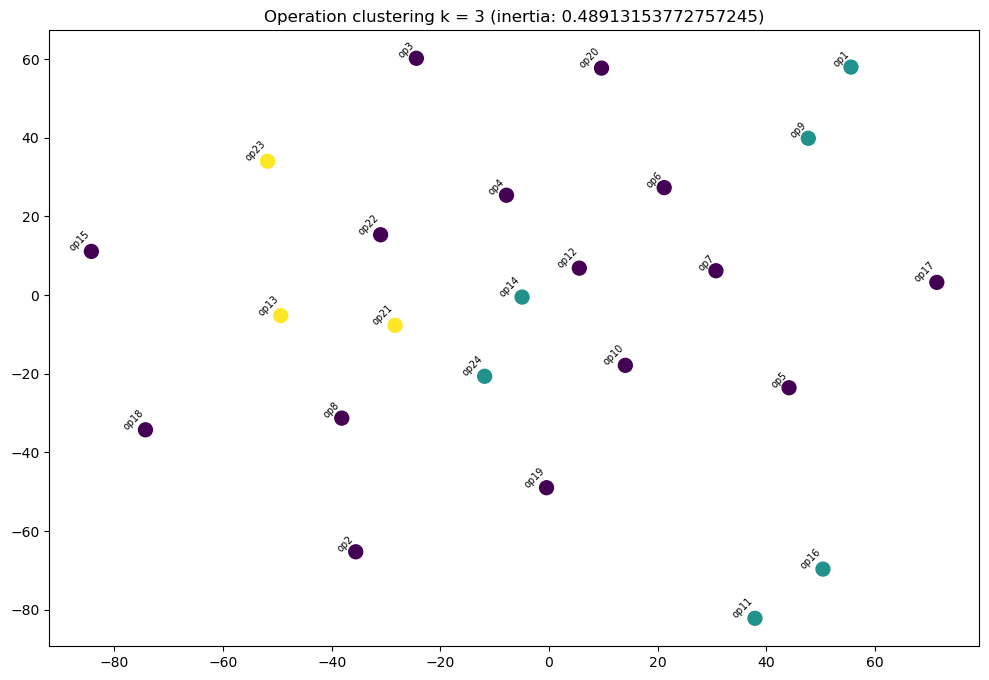

In [24]:
inertia_k3, kmed_labels_k3 = multiple_KMedioids(k=3) #k=3 following dendogram 

plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=kmed_labels_k3, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title(f'Operation clustering k = 3 (inertia: {inertia_k3})')
plt.show()

clusters are still fragmented

## Spectral clustering

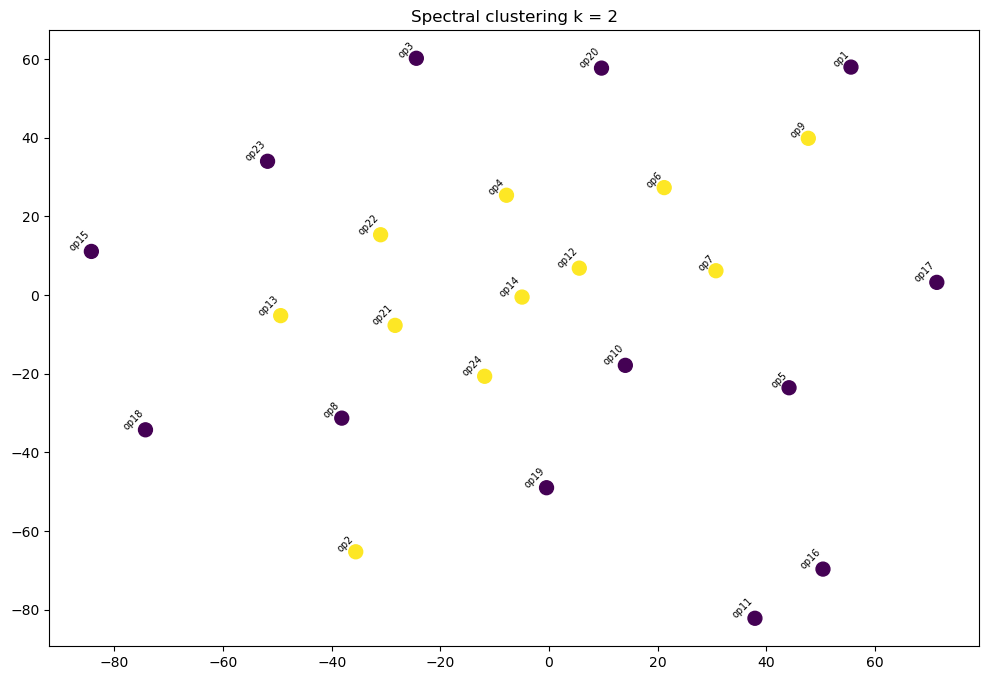

In [25]:
from sklearn.cluster import SpectralClustering


clustering = SpectralClustering(n_clusters=2, assign_labels='discretize', random_state=42, affinity = 'precomputed').fit(nDistMatrix)
spec_clustering_labels = clustering.labels_ 


plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=spec_clustering_labels, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title(f'Spectral clustering k = 2')
plt.show()

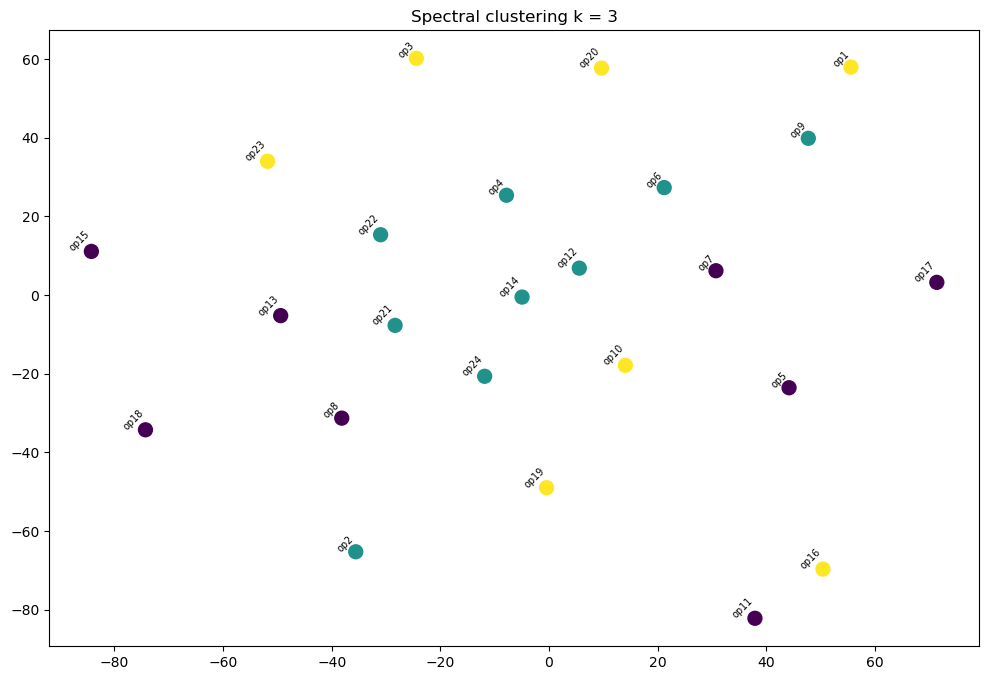

In [51]:
clusteringk3 = SpectralClustering(n_clusters=3, assign_labels='discretize', random_state=42, affinity = 'precomputed').fit(nDistMatrix)
spec_clustering_labels_k3 = clusteringk3.labels_ 


plt.figure(figsize=(12, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], 
            c=spec_clustering_labels_k3, s=100)
for i, op in enumerate(opLabels):
    plt.annotate(op, (embedding[i, 0], embedding[i, 1]), fontsize=7, ha='right', rotation=45)
plt.title(f'Spectral clustering k = 3')
plt.show()

## Evaluating cluster agreement 
- Using ARI and Fowlkes Mallows Index

In [52]:
from sklearn.metrics.cluster import adjusted_rand_score, fowlkes_mallows_score

#hiearchical cluster technically has 3 clusters
cluster_labels = [hierachical_labels, kmed_labels_k3, spec_clustering_labels_k3]

clustering_algorithms = ["Hiearchical clustering", "K-Medioids", "Spectral Clustering"]

In [53]:
for i, label in enumerate(cluster_labels):
    for j in range(i+1, len(cluster_labels)):
        print(f'{clustering_algorithms[i]}, {clustering_algorithms[j]} agreement')
        print("------------------------------------------")
        print("Labels:")
        print(f"    {clustering_algorithms[i]}: {label}")
        print(f"    {clustering_algorithms[j]}: {cluster_labels[j]}")

        print("Metrics:")
        print(f'    ARI: {adjusted_rand_score(label, cluster_labels[j])}')
        print(f'    FMI: {fowlkes_mallows_score(label, cluster_labels[j])}\n')



Hiearchical clustering, K-Medioids agreement
------------------------------------------
Labels:
    Hiearchical clustering: [2 2 2 1 1 1 1 1 2 1 2 1 2 1 2 2 2 2 1 2 1 1 2 1]
    K-Medioids: [1 0 0 0 0 0 0 0 1 0 1 0 2 1 0 1 0 0 0 0 2 0 2 1]
Metrics:
    ARI: 0.0025324469768914213
    FMI: 0.4630335825255442

Hiearchical clustering, Spectral Clustering agreement
------------------------------------------
Labels:
    Hiearchical clustering: [2 2 2 1 1 1 1 1 2 1 2 1 2 1 2 2 2 2 1 2 1 1 2 1]
    Spectral Clustering: [2 1 2 1 0 1 0 0 1 2 0 1 0 1 0 2 0 0 2 2 1 1 2 1]
Metrics:
    ARI: 0.07882089074014739
    FMI: 0.4342715744283826

K-Medioids, Spectral Clustering agreement
------------------------------------------
Labels:
    K-Medioids: [1 0 0 0 0 0 0 0 1 0 1 0 2 1 0 1 0 0 0 0 2 0 2 1]
    Spectral Clustering: [2 1 2 1 0 1 0 0 1 2 0 1 0 1 0 2 0 0 2 2 1 1 2 1]
Metrics:
    ARI: -0.04356403090580306
    FMI: 0.34229931163677635



Cluster aggreements are either worse or near random chance 

In [54]:
print(f'ARI: {adjusted_rand_score(kmed_labels_k2, spec_clustering_labels)}')
print(f'FMI: {fowlkes_mallows_score(kmed_labels_k2, spec_clustering_labels)}')

ARI: -0.009457129421599875
FMI: 0.5190218205512398
